<a href="https://colab.research.google.com/github/monicatom/Assignment/blob/main/car_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import pickle
from sklearn.ensemble import RandomForestRegressor

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
filepath='/content/drive/MyDrive/DSA_ICTAK/Pratice_Data/car_prediction_data.csv'
car=pd.read_csv(filepath)
car.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


EDA

In [4]:
car.shape

(301, 9)

In [6]:
car.size

2709

In [8]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [9]:
car.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [10]:
car.isna().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [11]:
car.nunique()

,0
Car_Name,98
Year,16
Selling_Price,156
Present_Price,147
Kms_Driven,206
Fuel_Type,3
Seller_Type,2
Transmission,2
Owner,3


In [12]:
car=car.drop("Car_Name",axis=1)

In [13]:
car.nunique()

,0
Year,16
Selling_Price,156
Present_Price,147
Kms_Driven,206
Fuel_Type,3
Seller_Type,2
Transmission,2
Owner,3


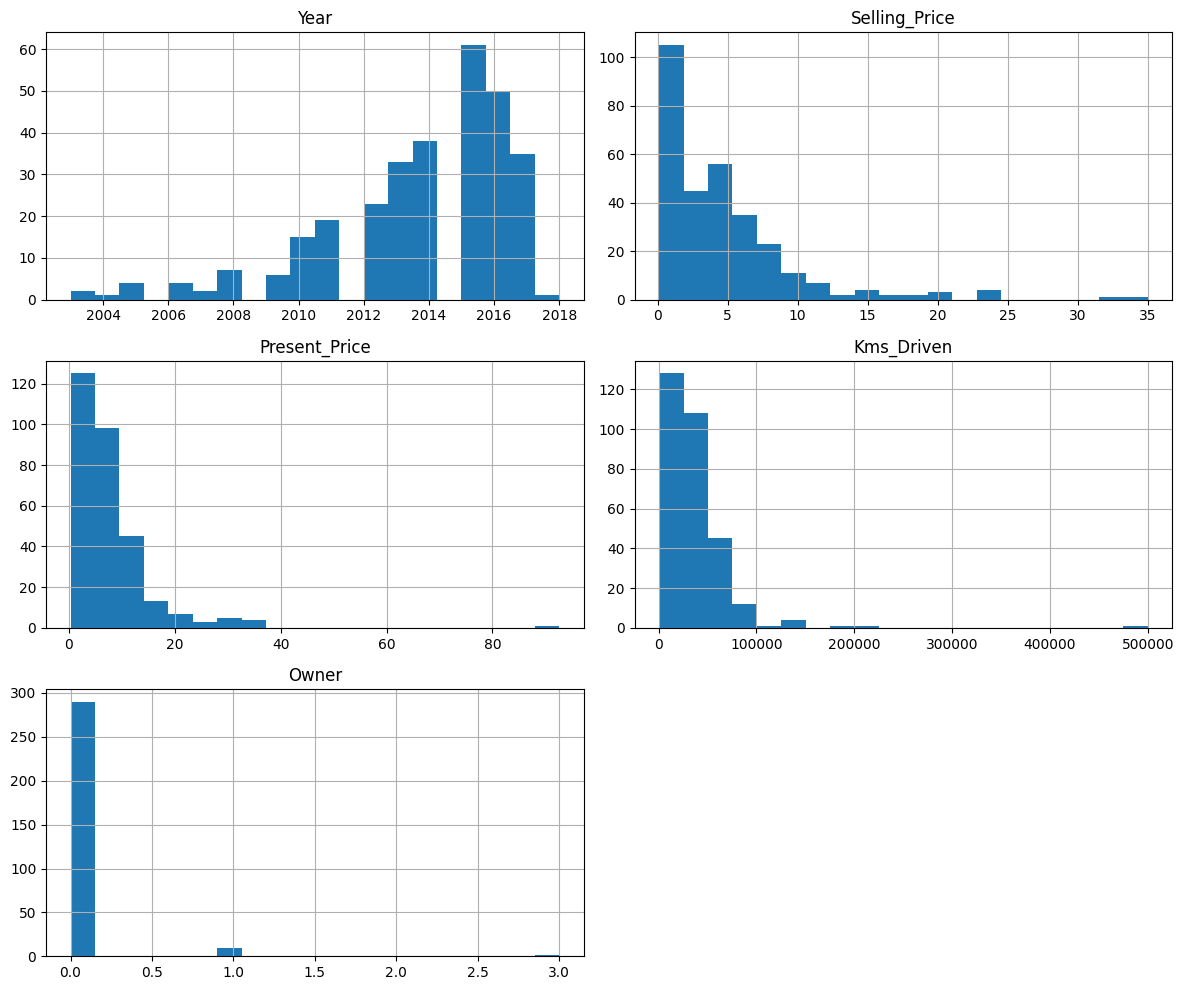

In [14]:
car.select_dtypes(include=["number"]).hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

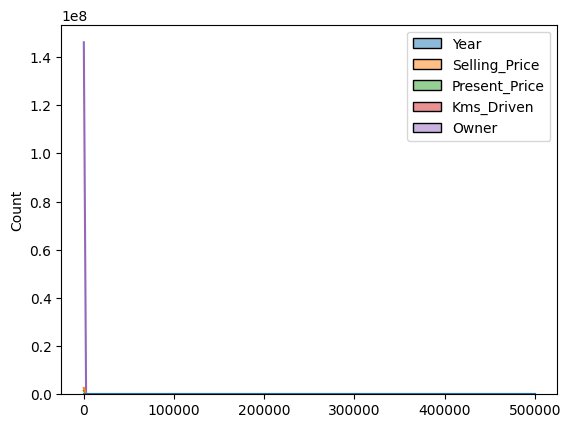

In [17]:
sns.histplot(car, bins=5, kde=True)
plt.show()

<Axes: >

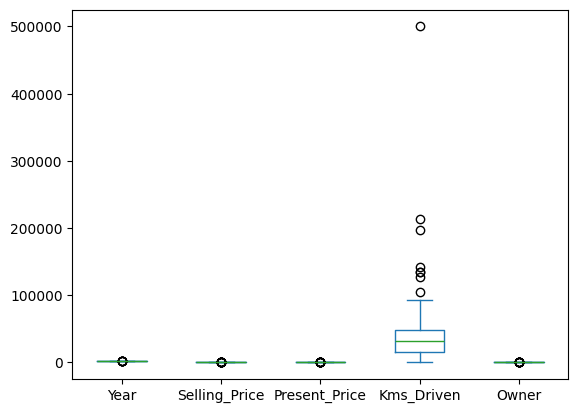

In [18]:
car.plot(kind="box")

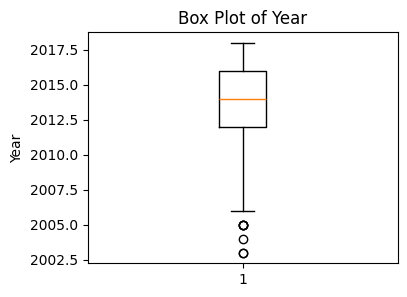

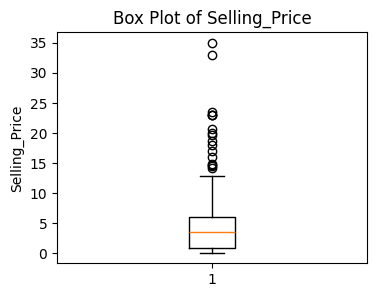

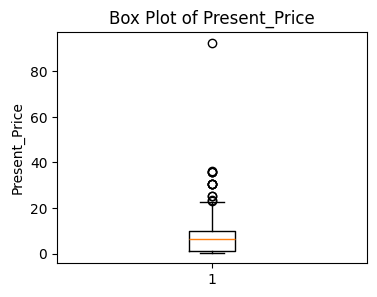

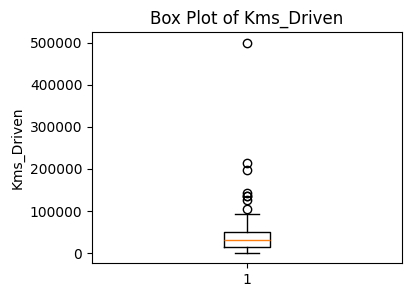

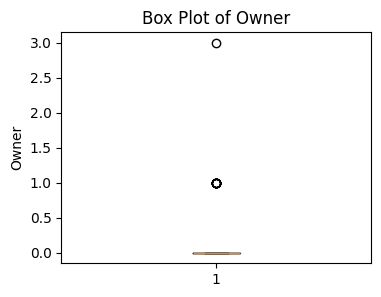

In [21]:
num_cols =car.select_dtypes(include=["number"]).columns
for col in num_cols:
  plt.figure(figsize=(4, 3))
  plt.boxplot(car[col])
  plt.title(f'Box Plot of {col}')
  plt.ylabel(col)
  plt.show()

Outlier

In [22]:
Q1 = car['Kms_Driven'].quantile(0.25)
Q3 = car['Kms_Driven'].quantile(0.75)
IQR = Q3 - Q1


In [23]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


In [24]:
car = car[
    (car['Kms_Driven'] >= lower_bound) &
    (car['Kms_Driven'] <= upper_bound)
]


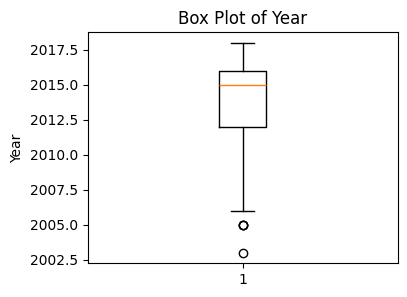

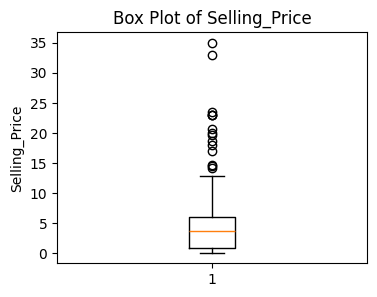

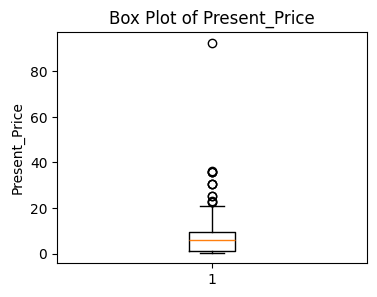

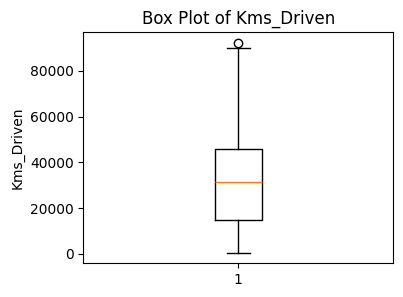

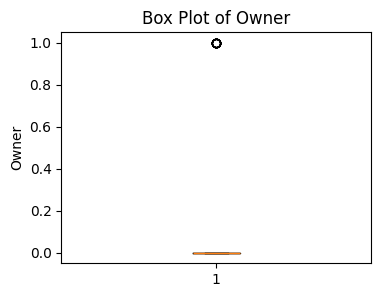

In [25]:
num_cols =car.select_dtypes(include=["number"]).columns
for col in num_cols:
  plt.figure(figsize=(4,3))
  plt.boxplot(car[col])
  plt.title(f'Box Plot of {col}')
  plt.ylabel(col)
  plt.show()

Encoding

In [26]:
car_train_encode = pd.get_dummies(car, drop_first=True,dtype=int)


In [27]:
car_train_encode

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,0,1,0,1
1,2013,4.75,9.54,43000,0,1,0,0,1
2,2017,7.25,9.85,6900,0,0,1,0,1
3,2011,2.85,4.15,5200,0,0,1,0,1
4,2014,4.60,6.87,42450,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,0,1,0,0,1
297,2015,4.00,5.90,60000,0,0,1,0,1
298,2009,3.35,11.00,87934,0,0,1,0,1
299,2017,11.50,12.50,9000,0,1,0,0,1


Scaling

In [28]:
scaler = MinMaxScaler()
data_scaled= scaler.fit_transform(car_train_encode)
data_scaled = pd.DataFrame(data_scaled, columns=car_train_encode.columns)


In [29]:
data_scaled

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,0.733333,0.093123,0.057109,0.288882,0.0,0.0,1.0,0.0,1.0
1,0.666667,0.133238,0.099913,0.463301,0.0,1.0,0.0,0.0,1.0
2,0.933333,0.204871,0.103273,0.069768,0.0,0.0,1.0,0.0,1.0
3,0.533333,0.078797,0.041504,0.051236,0.0,0.0,1.0,0.0,1.0
4,0.733333,0.128940,0.070980,0.457305,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
288,0.866667,0.269341,0.122237,0.365059,0.0,1.0,0.0,0.0,1.0
289,0.800000,0.111748,0.060468,0.648622,0.0,0.0,1.0,0.0,1.0
290,0.400000,0.093123,0.115735,0.953136,0.0,0.0,1.0,0.0,1.0
291,0.933333,0.326648,0.131990,0.092660,0.0,1.0,0.0,0.0,1.0


split the data into X and y

In [30]:
X=data_scaled.drop(['Selling_Price'],axis=1)
y=data_scaled['Selling_Price']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
X_train.shape

(234, 8)

In [33]:
X_test.shape

(59, 8)

linear regression

In [34]:
lin_model=LinearRegression()

In [35]:
lin_model.fit(X_train,y_train)

LinearRegression()

In [36]:
pickle.dump(lin_model, open("car_price_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(X.columns, open("features.pkl", "wb"))

In [37]:
print(X_train.columns)

Index(['Year', 'Present_Price', 'Kms_Driven', 'Owner', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol', 'Seller_Type_Individual', 'Transmission_Manual'],
      dtype='object')


In [38]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [39]:
pickle.dump(model, open("car_pred_model.pkl", "wb"))